In [1]:
# Cell 1: One-time installs (run once per fresh session)
!pip install -q timm pytorch-lightning torchmetrics seaborn scikit-learn thop opencv-python-headless "numpy<2"

In [2]:
# Cell 3: CONFIG — single source of truth for the whole notebook
class Config:
    # ---- Paths ----
    DATA_ROOT = "/teamspace/studios/this_studio/HVDROPDB_RetCam_Neo_Classification"
    RESULTS_ROOT = "results"

    # ---- Model identity ----
    MODEL_KEY = "ghostnetv2"
    BACKBONE  = "ghostnetv2_100.in1k"      # exact timm model string — GhostNetV2 only

    # ---- Reproducibility ----
    SEED = 42

    # ---- Data ----
    IMG_SIZE = 256                          # per preprocessing spec: resize to 256x256
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    VAL_FRAC = 0.15
    TEST_FRAC = 0.15

    # ---- Model ----
    PRETRAINED = True
    NUM_CLASSES = 1                         # binary head -> BCEWithLogitsLoss

    # ---- Training ----
    LR = 1e-5
    MAX_EPOCHS = 30

    # ---- Class mapping ----
    LABEL_MAP = {"Normal": 0, "ROP": 1}
    THRESHOLD = 0.5

    # ---- ROP risk banding (external inference report only) ----
    RISK_BANDS = [
        (0.00, 0.30, "Low"),
        (0.30, 0.50, "Borderline"),
        (0.50, 0.75, "Moderate"),
        (0.75, 1.01, "High"),
    ]

In [3]:
# Cell 2: Imports
import os, random, time, json
import numpy as np
import pandas as pd
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    accuracy_score, precision_score, recall_score, f1_score,
)

import timm
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

from torchvision import transforms
from PIL import Image

from torchmetrics.classification import (
    BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAccuracy
)

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Cell 4: Seed + GPU detection + output folders
def set_seed(seed=Config.SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU attached to this session — check Studio compute type before training.")

MODEL_DIR = os.path.join(Config.RESULTS_ROOT, Config.MODEL_KEY)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(os.path.join(MODEL_DIR, "figures"), exist_ok=True)
print(f"Outputs will be saved to: {MODEL_DIR}/")

Device: cuda
GPU: Tesla T4
Outputs will be saved to: results/ghostnetv2/


In [5]:
# Cell 5: Build file index — walk Normal/{Neo_Normal,RetCam_Normal} and ROP/{Neo_ROP,RetCam_ROP}
def build_index(data_root):
    records = []
    if not os.path.exists(data_root):
        raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root}")
    for cls_name, label in Config.LABEL_MAP.items():
        cls_dir = os.path.join(data_root, cls_name)
        if not os.path.isdir(cls_dir):
            raise FileNotFoundError(f"Missing class folder: {cls_dir}")
        camera_subdirs = [d for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
        if not camera_subdirs:
            raise FileNotFoundError(f"No camera subfolders found inside: {cls_dir}")
        for camera_subdir in camera_subdirs:
            camera = "Neo" if camera_subdir.startswith("Neo") else "RetCam"
            sub_path = os.path.join(cls_dir, camera_subdir)
            n_before = len(records)
            for fname in os.listdir(sub_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    records.append({"filepath": os.path.join(sub_path, fname),
                                     "label": label, "class_name": cls_name, "camera": camera})
            print(f"{cls_name}/{camera_subdir}: {len(records) - n_before} images")
    if not records:
        raise ValueError("No images found — check file extensions or folder structure.")
    return pd.DataFrame(records)

df = build_index(Config.DATA_ROOT)
print(f"\nTotal images: {len(df)}")
df.groupby(["class_name", "camera"]).size()

Normal/RetCam_Normal: 50 images
Normal/Neo_Normal: 50 images
ROP/RetCam_ROP: 50 images
ROP/Neo_ROP: 35 images

Total images: 185


class_name  camera
Normal      Neo       50
            RetCam    50
ROP         Neo       35
            RetCam    50
dtype: int64

In [6]:
# Cell 6: Stratified 70/15/15 split by class AND camera
df["strata"] = df["class_name"] + "_" + df["camera"]

train_df, temp_df = train_test_split(
    df, test_size=(Config.VAL_FRAC + Config.TEST_FRAC),
    stratify=df["strata"], random_state=Config.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=Config.TEST_FRAC / (Config.VAL_FRAC + Config.TEST_FRAC),
    stratify=temp_df["strata"], random_state=Config.SEED
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 129 | Val: 28 | Test: 28


In [7]:
# Cell 7: Retinal preprocessing pipeline
# Order (must match spec exactly): Remove Black Border -> Circular Retina Crop
# -> CLAHE -> Gamma Correction. (Resize / Normalize / Augment happen later,
# in the torchvision transforms — see SECTION 5.)

def remove_black_border(img_np, threshold=10):
    """Crops away the black background/letterboxing around the fundus image."""
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    if mask.sum() == 0:
        return img_np  # fallback: fully dark image, leave unchanged
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img_np[y0:y1, x0:x1]

def circular_crop(img_np):
    """Masks the border-removed image down to the circular fundus region."""
    h, w = img_np.shape[:2]
    center = (w // 2, h // 2)
    radius = min(center)
    circ_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(circ_mask, center, radius, 255, -1)
    return cv2.bitwise_and(img_np, img_np, mask=circ_mask)

def apply_clahe(img_np, clip_limit=2.0, tile_grid_size=(8, 8)):
    """CLAHE on the L channel of LAB space — boosts local contrast without distorting color."""
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

def gamma_correction(img_np, gamma=1.2):
    """gamma > 1 brightens midtones, gamma < 1 darkens them."""
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img_np, table)

def preprocess_retinal_image(img_pil, use_border_removal=True, use_circular_crop=True,
                              use_clahe=True, use_gamma=True, gamma_value=1.2):
    """
    Full pipeline, PIL in -> PIL out:
    Remove Black Border -> Circular Retina Crop -> CLAHE -> Gamma Correction
    """
    img_np = np.array(img_pil.convert("RGB"))
    if use_border_removal:
        img_np = remove_black_border(img_np)
    if use_circular_crop:
        img_np = circular_crop(img_np)
    if use_clahe:
        img_np = apply_clahe(img_np)
    if use_gamma:
        img_np = gamma_correction(img_np, gamma=gamma_value)
    return Image.fromarray(img_np)

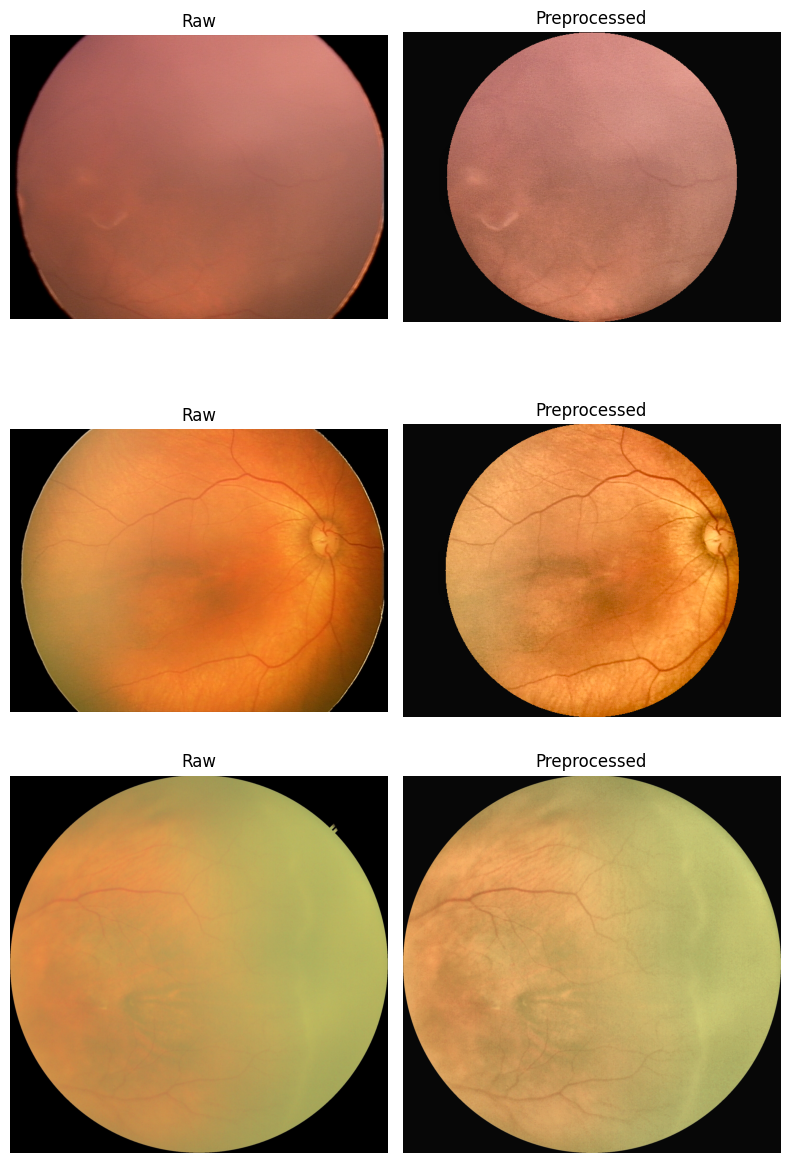

In [8]:
# Cell 8: Visual sanity check — raw vs preprocessed, on 3 sample images
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
sample_rows = df.sample(3, random_state=Config.SEED)
for i, (_, row) in enumerate(sample_rows.iterrows()):
    raw = Image.open(row["filepath"]).convert("RGB")
    processed = preprocess_retinal_image(raw)
    axes[i, 0].imshow(raw); axes[i, 0].set_title("Raw"); axes[i, 0].axis("off")
    axes[i, 1].imshow(processed); axes[i, 1].set_title("Preprocessed"); axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Cell 9: Resize -> ImageNet Normalization -> Augmentation (training only)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomResizedCrop(Config.IMG_SIZE, scale=(0.85, 1.0)),  # augmentation — train only
    transforms.RandomHorizontalFlip(),                                  # augmentation — train only
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [10]:
# Cell 10: Dataset wrapper (runs preprocessing, then transform) + DataLoaders
class ROPDataset(Dataset):
    def __init__(self, dataframe, transform=None, preprocess=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.preprocess:
            img = preprocess_retinal_image(img)   # border removal -> circular crop -> CLAHE -> gamma
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row["label"], dtype=torch.float32)

train_ds = ROPDataset(train_df, train_tf)
val_ds   = ROPDataset(val_df, eval_tf)
test_ds  = ROPDataset(test_df, eval_tf)

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

In [11]:
# Cell 11: GhostNetV2 backbone + classification head — the ONLY model definition in this notebook
class ROPModel(nn.Module):
    """
    GhostNetV2 (via timm) feature extractor + a small MLP head for binary
    ROP vs Normal classification. Feature dimension is probed with a dummy
    forward pass rather than trusted from .num_features, because some
    architectures (including GhostNetV2) report it incorrectly.
    """
    def __init__(self, backbone_name=Config.BACKBONE, pretrained=Config.PRETRAINED):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        with torch.no_grad():
            dummy = torch.randn(1, 3, Config.IMG_SIZE, Config.IMG_SIZE)
            feat_dim = self.backbone(dummy).shape[1]
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, Config.NUM_CLASSES),
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats).squeeze(1)   # raw logits — BCEWithLogitsLoss expects logits

In [12]:
# Cell 12: Single LightningModule — used identically by training, checkpoint
# loading, evaluation, and inference. This is the only pl.LightningModule
# in the notebook.
class ROPClassifier(pl.LightningModule):
    def __init__(self, backbone_name=Config.BACKBONE, lr=Config.LR, threshold=Config.THRESHOLD):
        super().__init__()
        self.save_hyperparameters()
        self.model = ROPModel(backbone_name)
        self.criterion = nn.BCEWithLogitsLoss()   # binary classification -> logits + BCE-with-logits

        for split in ["train", "val", "test"]:
            setattr(self, f"{split}_acc",  BinaryAccuracy(threshold=self.hparams.threshold))
            setattr(self, f"{split}_prec", BinaryPrecision(threshold=self.hparams.threshold))
            setattr(self, f"{split}_rec",  BinaryRecall(threshold=self.hparams.threshold))
            setattr(self, f"{split}_f1",   BinaryF1Score(threshold=self.hparams.threshold))

    def forward(self, x):
        return self.model(x)   # returns raw logits

    def _step(self, batch, split):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        probs = torch.sigmoid(logits)

        getattr(self, f"{split}_acc")(probs, y.int())
        getattr(self, f"{split}_prec")(probs, y.int())
        getattr(self, f"{split}_rec")(probs, y.int())
        getattr(self, f"{split}_f1")(probs, y.int())

        self.log(f"{split}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_acc",  getattr(self, f"{split}_acc"),  prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_f1",   getattr(self, f"{split}_f1"),   on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, batch_idx):   return self._step(batch, "train")
    def validation_step(self, batch, batch_idx): return self._step(batch, "val")
    def test_step(self, batch, batch_idx):        return self._step(batch, "test")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [13]:
# Cell 13: Trainer setup — checkpoints on val_f1, CSV logging
checkpoint_cb = ModelCheckpoint(
    monitor="val_f1", mode="max", save_top_k=1,
    dirpath=os.path.join(MODEL_DIR, "checkpoints"),
    filename="best-{epoch:02d}-{val_f1:.4f}",
)
logger = CSVLogger(Config.RESULTS_ROOT, name=f"{Config.MODEL_KEY}_logs")

model = ROPClassifier(backbone_name=Config.BACKBONE, lr=Config.LR, threshold=Config.THRESHOLD)

trainer = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_cb],
    logger=logger,
    log_every_n_steps=10,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [14]:
# Cell 14: Run training, track wall-clock time for the summary logs
training_start_time = time.time()
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
training_time_sec = time.time() - training_start_time
print(f"\nTraining time: {training_time_sec/60:.2f} min")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /teamspace/studios/this_studio/results/ghostnetv2/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ ROPModel          │  5.0 M │ train │     0 │
│ 1  │ criterion  │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2  │ train_acc  │ BinaryAccuracy    │      0 │ train │     0 │
│ 3  │ train_prec │ BinaryPrecision   │      0 │ train │     0 │
│ 4  │ train_rec  │ BinaryRecall      │      0 │ train │     0 │
│ 5  │ train_f1   │ BinaryF1Score     │      0 │ train │     0 │
│ 6  │ val_acc    │ BinaryAccuracy    │      0 │ train │     0 │
│ 7  │ val_prec   │ BinaryPrecision   │      0 │ train │     0 │
│ 8  │ val_rec    │ BinaryRecall      │      0 │ train │     0 │
│ 9  │ val_f1     │ BinaryF1Score     │      0 │ train │     0 │
│ 10 │ test_acc   │ BinaryAccuracy    │      0 │ train │     0 │
│ 11 │ test_prec  │ BinaryPrecision   │      0 │ train │     0 │
│ 12 │ test_rec   │ BinaryRecall      │      0 │ train │     0 │
│ 13 │ test_f1    │ BinaryF1Score     │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 5.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.0 M                                                                                                
Total estimated model params size (MB): 20.160                                                                     
Modules in train mode: 543                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=30` reached.



Training time: 8.94 min


In [15]:
print(checkpoint_cb.monitor)

val_f1


In [ ]:
import os
import glob

ckpt_dir = os.path.join(MODEL_DIR, "checkpoints")
ckpt_files = sorted(glob.glob(os.path.join(ckpt_dir, "*.ckpt")))
print("Found checkpoints:", ckpt_files)

best_ckpt_path = ckpt_files[-1] if ckpt_files else None
print("Using checkpoint:", best_ckpt_path)

eval_model = ROPClassifier.load_from_checkpoint(best_ckpt_path)
eval_model.to(device).eval()

In [ ]:
print(repr(checkpoint_cb.best_model_path))

In [ ]:
# Cell 15: Reload best checkpoint for clean (no-augmentation) evaluation
best_ckpt_path = checkpoint_cb.best_model_path
print("Best checkpoint:", best_ckpt_path)

eval_model = ROPClassifier.load_from_checkpoint(best_ckpt_path)
eval_model.to(device).eval()

train_eval_loader = DataLoader(ROPDataset(train_df, eval_tf), batch_size=Config.BATCH_SIZE, shuffle=False)

In [ ]:
print(checkpoint_cb.best_model_path)
print(checkpoint_cb.best_k_models)

In [ ]:
# Cell 16: evaluate() — the ONLY evaluation function in the notebook.
def evaluate(model, loader, dataframe, threshold=Config.THRESHOLD):
    y_true, y_pred, y_probs = [], [], []
    inference_times = []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            if device.type == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter()
            logits = model(images)
            if device.type == "cuda": torch.cuda.synchronize()
            inference_times.append((time.perf_counter() - t0) / images.size(0))

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            y_true.extend(labels.numpy()); y_pred.extend(preds); y_probs.extend(probs)

    y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=["Normal", "ROP"], output_dict=True, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "threshold": threshold,
        "accuracy": report["accuracy"],
        "precision": report["ROP"]["precision"],
        "recall_sensitivity": report["ROP"]["recall"],
        "specificity": specificity,
        "f1_score": report["ROP"]["f1-score"],
        "roc_auc": roc_auc_score(y_true, y_probs),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohens_kappa": cohen_kappa_score(y_true, y_pred),
        "avg_inference_time_sec_per_image": float(np.mean(inference_times)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }

    if dataframe is not None:
        d = dataframe.reset_index(drop=True).copy()
        d["pred"] = y_pred
        for cam in ["Neo", "RetCam"]:
            sub = d[d["camera"] == cam]
            if len(sub) > 0:
                metrics[f"{cam.lower()}_accuracy"] = float((sub["pred"] == sub["label"]).mean())
                metrics[f"{cam.lower()}_n"] = len(sub)

    return metrics, y_true, y_pred, y_probs

In [ ]:
# Cell 17: Run evaluation on train / val / test — all three use Config.THRESHOLD
train_metrics, *_ = evaluate(eval_model, train_eval_loader, train_df, threshold=Config.THRESHOLD)
val_metrics, *_   = evaluate(eval_model, val_loader, val_df, threshold=Config.THRESHOLD)
test_metrics, y_true_test, y_pred_test, y_probs_test = evaluate(
    eval_model, test_loader, test_df, threshold=Config.THRESHOLD
)

print("TRAIN:", {k: v for k, v in train_metrics.items() if k != "confusion_matrix"})
print("VAL:  ", {k: v for k, v in val_metrics.items() if k != "confusion_matrix"})
print("TEST: ", {k: v for k, v in test_metrics.items() if k != "confusion_matrix"})

In [ ]:
# Cell 18: Threshold sweep — for inspection only, does NOT affect training
# or overwrite Config.THRESHOLD anywhere else in the notebook.
def threshold_sweep(y_true, y_probs, thresholds=np.arange(0.10, 0.91, 0.05)):
    rows = []
    for t in thresholds:
        preds = (y_probs > t).astype(int)
        rows.append({
            "threshold": round(float(t), 2),
            "accuracy": accuracy_score(y_true, preds),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
        })
    return pd.DataFrame(rows)

sweep_df = threshold_sweep(y_true_test, y_probs_test)
print(f"Threshold sweep on TEST set (current Config.THRESHOLD = {Config.THRESHOLD}):")
print(sweep_df.to_string(index=False))

In [ ]:
# Cell 19: Model size stats
num_params = sum(p.numel() for p in eval_model.parameters())
trainable_params = sum(p.numel() for p in eval_model.parameters() if p.requires_grad)
print(f"Total params: {num_params:,} | Trainable: {trainable_params:,}")


In [ ]:
# Cell 20: Loss / accuracy curves from training log
log_path = os.path.join(logger.log_dir, "metrics.csv")
metrics_df = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cols, ax, title in [(["train_loss","val_loss"], axes[0], "Loss"), (["train_acc","val_acc"], axes[1], "Accuracy")]:
    for c in cols:
        if c in metrics_df.columns:
            sub = metrics_df.dropna(subset=[c])
            ax.plot(sub["epoch"], sub[c], label=c)
    ax.set_title(f"{Config.MODEL_KEY} — {title}"); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "training_curves.png"), dpi=150)
plt.show()

In [ ]:
# Cell 21: Save everything — predictions CSV, metrics CSV, summary.json, master comparison row
pred_df = test_df.reset_index(drop=True).copy()
pred_df["y_true"] = y_true_test
pred_df["y_pred"] = y_pred_test
pred_df["y_prob"] = y_probs_test
pred_df.to_csv(os.path.join(MODEL_DIR, "predictions.csv"), index=False)

per_model_df = pd.DataFrame({"train": train_metrics, "val": val_metrics, "test": test_metrics}).T
per_model_df.to_csv(os.path.join(MODEL_DIR, "metrics.csv"))

with open(os.path.join(MODEL_DIR, "summary.json"), "w") as f:
    json.dump({
        "model_key": Config.MODEL_KEY, "backbone": Config.BACKBONE,
        "threshold": Config.THRESHOLD, "checkpoint": best_ckpt_path,
        "num_params": num_params, "training_time_sec": training_time_sec,
        "train": train_metrics, "val": val_metrics, "test": test_metrics,
    }, f, indent=2)

master_path = os.path.join(Config.RESULTS_ROOT, "master_comparison.csv")
row = {
    "model": Config.MODEL_KEY, "backbone": Config.BACKBONE, "threshold": Config.THRESHOLD,
    "num_params": num_params, "training_time_min": round(training_time_sec / 60, 2),
    "train_accuracy": train_metrics["accuracy"], "val_accuracy": val_metrics["accuracy"],
    "test_accuracy": test_metrics["accuracy"], "precision": test_metrics["precision"],
    "recall_sensitivity": test_metrics["recall_sensitivity"], "specificity": test_metrics["specificity"],
    "f1_score": test_metrics["f1_score"], "roc_auc": test_metrics["roc_auc"],
    "balanced_accuracy": test_metrics["balanced_accuracy"], "mcc": test_metrics["mcc"],
    "cohens_kappa": test_metrics["cohens_kappa"],
    "neo_accuracy": test_metrics.get("neo_accuracy"), "retcam_accuracy": test_metrics.get("retcam_accuracy"),
    "avg_inference_time_sec_per_image": test_metrics["avg_inference_time_sec_per_image"],
    "confusion_matrix": test_metrics["confusion_matrix"], "checkpoint_path": best_ckpt_path,
}

if os.path.exists(master_path):
    master_df = pd.read_csv(master_path)
    master_df = master_df[master_df["model"] != Config.MODEL_KEY]
    master_df = pd.concat([master_df, pd.DataFrame([row])], ignore_index=True)
else:
    master_df = pd.DataFrame([row])

master_df.to_csv(master_path, index=False)
print(f"\n✅ Saved: {MODEL_DIR}/  (checkpoint, predictions.csv, metrics.csv, summary.json, figures/)")
print(f"✅ Appended to: {master_path}")
master_df

In [ ]:
# Cell 22: Per-camera performance breakdown (bias check)
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_test
test_df_reset["prob"] = y_probs_test

for cam in ["Neo", "RetCam"]:
    sub = test_df_reset[test_df_reset["camera"] == cam]
    if len(sub) > 0:
        acc = (sub["pred"] == sub["label"]).mean()
        print(f"{cam}: n={len(sub)}, accuracy={acc:.4f}")

In [ ]:
# Cell 23: Confusion matrix (threshold = Config.THRESHOLD, same as everywhere else)
cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","ROP"], yticklabels=["Normal","ROP"], ax=ax)
ax.set_title(f"{Config.MODEL_KEY} — Confusion Matrix (thr={Config.THRESHOLD})")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
# Cell 24: ROC + Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fpr, tpr, _ = roc_curve(y_true_test, y_probs_test)
axes[0].plot(fpr, tpr); axes[0].plot([0,1],[0,1],'--',color='gray')
axes[0].set_title(f"ROC (AUC={test_metrics['roc_auc']:.3f})"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

prec, rec, _ = precision_recall_curve(y_true_test, y_probs_test)
axes[1].plot(rec, prec); axes[1].set_title("Precision-Recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "roc_pr_curves.png"), dpi=150)
plt.show()

In [ ]:
# Cell 25: Grad-CAM — generic via timm's forward_features/forward_head convention
def generate_gradcam(model, image_tensor):
    """image_tensor: single preprocessed image, shape (1,3,H,W)."""
    model.eval()
    image_tensor = image_tensor.to(device).requires_grad_(False)

    backbone = model.model.backbone
    head = model.model.head

    feats = backbone.forward_features(image_tensor)
    feats.retain_grad()
    pooled = backbone.forward_head(feats, pre_logits=True)
    logit = head(pooled).squeeze(1)

    model.zero_grad()
    logit.backward()

    gradients = feats.grad[0]
    activations = feats[0].detach()
    weights = gradients.mean(dim=(1, 2))

    cam = torch.relu((weights[:, None, None] * activations).sum(0))
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (Config.IMG_SIZE, Config.IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, torch.sigmoid(logit).item()

def overlay_heatmap(image_pil, cam):
    img = np.array(image_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE))).astype(np.float32) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET).astype(np.float32) / 255.0
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = 0.55 * img + 0.45 * heatmap
    return np.clip(overlay, 0, 1)

def plot_gradcam(img_pil, model, threshold=Config.THRESHOLD, title_prefix=""):
    """Shows Input Image | GradCAM Overlay, with Prediction + Confidence in the title."""
    tensor = eval_tf(img_pil).unsqueeze(0)
    cam, prob = generate_gradcam(model, tensor)
    pred_label = "ROP" if prob > threshold else "Normal"
    overlay = overlay_heatmap(img_pil, cam)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE)))
    axes[0].set_title("Input Image"); axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"{title_prefix}Prediction: {pred_label} | Confidence: {prob:.3f}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    return pred_label, prob

In [ ]:
# Cell 26: Grad-CAM on interesting cases — true positive vs false negative
pred_df_check = test_df.reset_index(drop=True).copy()
pred_df_check["y_true"] = y_true_test
pred_df_check["y_pred"] = y_pred_test
pred_df_check["y_prob"] = y_probs_test

true_positive = pred_df_check[(pred_df_check.y_true == 1) & (pred_df_check.y_pred == 1)].sort_values("y_prob", ascending=False).head(1)
false_negative = pred_df_check[(pred_df_check.y_true == 1) & (pred_df_check.y_pred == 0)].head(1)

for label, subset in [("True Positive", true_positive), ("False Negative", false_negative)]:
    if len(subset):
        row = subset.iloc[0]
        img_pil = Image.open(row["filepath"]).convert("RGB")
        plot_gradcam(img_pil, eval_model, title_prefix=f"[{label}] camera={row['camera']} | ")

In [ ]:
# Cell 27: External / unseen image prediction
# Outputs: Prediction, Confidence Score, ROP Risk Score, Camera Prediction
# (Neo/RetCam — reported only if you pass it in; not fabricated), Inference Time.
def risk_band(prob):
    for lo, hi, label in Config.RISK_BANDS:
        if lo <= prob < hi:
            return label
    return "Unknown"

def predict_external_image(image_path, model=eval_model, camera=None,
                            threshold=Config.THRESHOLD, show_gradcam=True):
    img_pil = Image.open(image_path).convert("RGB")
    processed = preprocess_retinal_image(img_pil)
    tensor = eval_tf(processed).unsqueeze(0).to(device)

    model.eval()
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        logit = model(tensor)
        prob = torch.sigmoid(logit).item()
    if device.type == "cuda": torch.cuda.synchronize()
    inference_time_ms = (time.perf_counter() - t0) * 1000

    pred_label = "ROP" if prob > threshold else "Normal"
    camera_label = camera if camera in ("Neo", "RetCam") else "Not specified"

    print(f"Image:               {image_path}")
    print(f"Prediction:          {pred_label}")
    print(f"Confidence Score:    {prob:.4f}")
    print(f"ROP Risk Score:      {risk_band(prob)}")
    print(f"Camera Prediction:   {camera_label}")
    print(f"Inference Time:      {inference_time_ms:.2f} ms")

    if show_gradcam:
        plot_gradcam(img_pil, model, threshold=threshold)

    return {
        "prediction": pred_label, "confidence_score": prob, "rop_risk_score": risk_band(prob),
        "camera_prediction": camera_label, "inference_time_ms": inference_time_ms,
    }

# Usage — update the path (and camera, if known) for your new image
predict_external_image("/teamspace/studios/this_studio/rop_testing.jpg", camera=None)

In [ ]:
# Cell: Load aggregated results
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

master_df = pd.read_csv("results/master_comparison.csv")
master_df = master_df[master_df["model"].isin(
    ["resnet18", "densenet121", "efficientnetb0", "ghostnetv2", "convnextv2_tiny"]
)].reset_index(drop=True)
master_df[["model","test_accuracy","precision","recall_sensitivity","f1_score","roc_auc"]]

In [ ]:
# Cell: Publication-style grouped bar chart
metrics_to_plot = ["test_accuracy", "precision", "recall_sensitivity", "f1_score", "roc_auc"]
labels = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

x = np.arange(len(master_df))
width = 0.15
fig, ax = plt.subplots(figsize=(11, 5))

for i, (m, lbl) in enumerate(zip(metrics_to_plot, labels)):
    ax.bar(x + i*width, master_df[m], width, label=lbl)

ax.set_xticks(x + width*2)
ax.set_xticklabels(master_df["model"], rotation=15)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison — ROP Binary Classification (HVDROPDB)")
ax.legend(loc="lower right", ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures_model_comparison_bars.png", dpi=300)
plt.show()

In [ ]:
# Cell: Overlaid ROC curves for all 5 models (reuses saved predictions.csv per model)
fig, ax = plt.subplots(figsize=(6, 6))
for model_key in master_df["model"]:
    pred_path = f"results/{model_key}/predictions.csv"
    if not os.path.exists(pred_path):
        print(f"⚠️ Missing predictions.csv for {model_key}, skipping"); continue
    pdf = pd.read_csv(pred_path)
    fpr, tpr, _ = roc_curve(pdf["y_true"], pdf["y_prob"])
    auc = master_df.loc[master_df["model"]==model_key, "roc_auc"].values[0]
    ax.plot(fpr, tpr, label=f"{model_key} (AUC={auc:.3f})")

ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("results/figures_roc_comparison.png", dpi=300)
plt.show()

In [ ]:
# Cell: Overlaid ROC curves for all 5 models (reuses saved predictions.csv per model)
fig, ax = plt.subplots(figsize=(6, 6))
for model_key in master_df["model"]:
    pred_path = f"results/{model_key}/predictions.csv"
    if not os.path.exists(pred_path):
        print(f"⚠️ Missing predictions.csv for {model_key}, skipping"); continue
    pdf = pd.read_csv(pred_path)
    fpr, tpr, _ = roc_curve(pdf["y_true"], pdf["y_prob"])
    auc = master_df.loc[master_df["model"]==model_key, "roc_auc"].values[0]
    ax.plot(fpr, tpr, label=f"{model_key} (AUC={auc:.3f})")

ax.plot([0,1],[0,1],'--', color='gray')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("results/figures_roc_comparison.png", dpi=300)
plt.show()

In [ ]:
# Cell: Confusion matrix grid, all 5 models in one figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, model_key in enumerate(master_df["model"]):
    cm = eval(master_df.loc[master_df["model"]==model_key, "confusion_matrix"].values[0])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Normal","ROP"], yticklabels=["Normal","ROP"], ax=axes[i])
    axes[i].set_title(model_key)
for j in range(len(master_df), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("results/figures_confusion_matrix_grid.png", dpi=300)
plt.show()

In [ ]:
# Cell: Best model selection — ranked by F1 primary, ROC-AUC tiebreak
ranked = master_df.sort_values(["f1_score", "roc_auc"], ascending=False).reset_index(drop=True)
print(ranked[["model","f1_score","roc_auc","test_accuracy","precision","recall_sensitivity"]])
BEST_MODEL_KEY = ranked.iloc[0]["model"]
BEST_BACKBONE = ranked.iloc[0]["backbone"]
print(f"\n✅ Best model: {BEST_MODEL_KEY} ({BEST_BACKBONE})")

In [ ]:
# Cell: SE block + GeM pooling — building blocks for the proposed head
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: learns per-channel importance weights."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w

class GeMPooling(nn.Module):
    """Generalized-Mean pooling — learnable interpolation between avg and max pooling."""
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps
    def forward(self, x):
        x = x.clamp(min=self.eps).pow(self.p)
        x = F.adaptive_avg_pool2d(x, 1).pow(1.0 / self.p)
        return x.flatten(1)

In [ ]:
# Cell: Proposed model — SE-GeM Enhanced Head on top of the best backbone
class ProposedROPModel(nn.Module):
    def __init__(self, backbone_name, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained,
                                           num_classes=0, global_pool="")  # keep spatial map, no pooling
        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            feat_map = self.backbone.forward_features(dummy)
            channels = feat_map.shape[1]

        self.se = SEBlock(channels)
        self.gem = GeMPooling()

        self.classifier = nn.Sequential(
            nn.Linear(channels, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 64), nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        feat_map = self.backbone.forward_features(x)   # (B, C, H, W)
        feat_map = self.se(feat_map)                     # channel-recalibrated
        pooled = self.gem(feat_map)                       # (B, C) — learnable pooling
        return self.classifier(pooled).squeeze(1)

In [ ]:
# Cell: LightningModule for the proposed model — identical metric setup, just wraps ProposedROPModel
class ProposedROPClassifier(pl.LightningModule):
    def __init__(self, backbone_name, lr=1e-5):
        super().__init__()
        self.save_hyperparameters()
        self.model = ProposedROPModel(backbone_name)
        self.criterion = nn.BCEWithLogitsLoss()
        for split in ["train", "val", "test"]:
            setattr(self, f"{split}_acc", BinaryAccuracy())
            setattr(self, f"{split}_prec", BinaryPrecision())
            setattr(self, f"{split}_rec", BinaryRecall())
            setattr(self, f"{split}_f1", BinaryF1Score())

    def forward(self, x): return self.model(x)

    def _step(self, batch, split):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        getattr(self, f"{split}_acc")(preds, y.int())
        getattr(self, f"{split}_prec")(preds, y.int())
        getattr(self, f"{split}_rec")(preds, y.int())
        getattr(self, f"{split}_f1")(preds, y.int())
        self.log(f"{split}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_acc", getattr(self, f"{split}_acc"), prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_f1", getattr(self, f"{split}_f1"), on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, batch_idx): return self._step(batch, "train")
    def validation_step(self, batch, batch_idx): return self._step(batch, "val")
    def test_step(self, batch, batch_idx): return self._step(batch, "test")
    def configure_optimizers(self): return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [ ]:
# Cell: Drop-last loader for SE-GeM training only (avoids a batch-size-1 crash in BatchNorm1d)
proposed_train_loader = DataLoader(
    train_ds, batch_size=Config.BATCH_SIZE, shuffle=True,
    num_workers=Config.NUM_WORKERS, drop_last=True
)

In [ ]:
# Cell: Train the proposed SE-GeM model — backbone locked explicitly to GhostNetV2
# (not auto-selected from ranked.iloc[0] — this is a deliberate override, not a bug)
import torch.nn.functional as F
PROPOSED_MODEL_KEY = "se_gem_ghostnetv2"
PROPOSED_BACKBONE  = "ghostnetv2_100.in1k

PROPOSED_DIR = os.path.join(Config.RESULTS_ROOT, PROPOSED_MODEL_KEY)
os.makedirs(os.path.join(PROPOSED_DIR, "figures"), exist_ok=True)

proposed_ckpt_cb = ModelCheckpoint(
    monitor="val_f1", mode="max", save_top_k=1,
    dirpath=os.path.join(PROPOSED_DIR, "checkpoints"),
    filename="best-{epoch:02d}-{val_f1:.4f}"
)
proposed_logger = CSVLogger(Config.RESULTS_ROOT, name=f"{PROPOSED_MODEL_KEY}_logs")

proposed_model = ProposedROPClassifier(backbone_name=PROPOSED_BACKBONE, lr=Config.LR)

proposed_trainer = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS, accelerator="auto", devices="auto",
    callbacks=[proposed_ckpt_cb], logger=proposed_logger, log_every_n_steps=10,
)

proposed_start_time = time.time()
proposed_trainer.fit(proposed_model, train_dataloaders=proposed_train_loader, val_dataloaders=val_loader)
proposed_training_time_sec = time.time() - proposed_start_time
print(f"\nTraining time: {proposed_training_time_sec/60:.2f} min")


In [ ]:
# Cell: Reload best SE-GeM checkpoint for clean (no-augmentation) evaluation
proposed_best_ckpt_path = proposed_ckpt_cb.best_model_path
print("Best checkpoint:", proposed_best_ckpt_path)

proposed_eval_model = ProposedROPClassifier.load_from_checkpoint(proposed_best_ckpt_path)
proposed_eval_model.to(device).eval()

In [ ]:
# Cell: Evaluate SE-GeM on train/val/test — reuses the exact same evaluate() function as all 5 baselines
proposed_train_metrics, *_ = evaluate(proposed_eval_model, train_eval_loader, train_df)
proposed_val_metrics, *_ = evaluate(proposed_eval_model, val_loader, val_df)
proposed_test_metrics, y_true_test_proposed, y_pred_test_proposed, y_probs_test_proposed = evaluate(
    proposed_eval_model, test_loader, test_df
)

print("TRAIN:", {k: v for k, v in proposed_train_metrics.items() if k != "confusion_matrix"})
print("VAL:  ", {k: v for k, v in proposed_val_metrics.items() if k != "confusion_matrix"})
print("TEST: ", {k: v for k, v in proposed_test_metrics.items() if k != "confusion_matrix"})


In [ ]:
# Cell: SE-GeM parameter count — for the comparison table (should be close to plain GhostNetV2 + a small SE/GeM overhead)
proposed_num_params = sum(p.numel() for p in proposed_eval_model.parameters())
proposed_trainable_params = sum(p.numel() for p in proposed_eval_model.parameters() if p.requires_grad)
print(f"Total params: {proposed_num_params:,} | Trainable: {proposed_trainable_params:,}")

# Sanity check vs. baseline GhostNetV2, if it's already been run in this results/ tree
baseline_summary_path = os.path.join(Config.RESULTS_ROOT, "ghostnetv2", "summary.json")
if os.path.exists(baseline_summary_path):
    with open(baseline_summary_path) as f:
        baseline_params = json.load(f)["num_params"]
    delta = proposed_num_params - baseline_params
    print(f"vs. plain GhostNetV2 baseline: {baseline_params:,} params  (Δ = {delta:+,}, "
          f"{100*delta/baseline_params:.2f}%)")


In [ ]:
# Cell: SE-GeM confusion matrix + ROC + PR curves — saved as figures
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = np.array(proposed_test_metrics["confusion_matrix"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","ROP"], yticklabels=["Normal","ROP"], ax=axes[0])
axes[0].set_title(f"{PROPOSED_MODEL_KEY} — Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_true_test_proposed, y_probs_test_proposed)
axes[1].plot(fpr, tpr); axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title(f"ROC (AUC={proposed_test_metrics['roc_auc']:.3f})"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")

prec, rec, _ = precision_recall_curve(y_true_test_proposed, y_probs_test_proposed)
axes[2].plot(rec, prec); axes[2].set_title("Precision-Recall"); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.savefig(os.path.join(PROPOSED_DIR, "figures", "eval_curves.png"), dpi=150)
plt.show()


In [ ]:
# Cell: Save everything for SE-GeM — predictions CSV, metrics CSV, summary.json,
# and append as a 6th row to the shared master comparison table
pred_df_proposed = test_df.reset_index(drop=True).copy()
pred_df_proposed["y_true"] = y_true_test_proposed
pred_df_proposed["y_pred"] = y_pred_test_proposed
pred_df_proposed["y_prob"] = y_probs_test_proposed
pred_df_proposed.to_csv(os.path.join(PROPOSED_DIR, "predictions.csv"), index=False)

per_model_df_proposed = pd.DataFrame(
    {"train": proposed_train_metrics, "val": proposed_val_metrics, "test": proposed_test_metrics}
).T
per_model_df_proposed.to_csv(os.path.join(PROPOSED_DIR, "metrics.csv"))

with open(os.path.join(PROPOSED_DIR, "summary.json"), "w") as f:
    json.dump({
        "model_key": PROPOSED_MODEL_KEY, "backbone": PROPOSED_BACKBONE,
        "checkpoint": proposed_best_ckpt_path, "num_params": proposed_num_params,
        "training_time_sec": proposed_training_time_sec,
        "train": proposed_train_metrics, "val": proposed_val_metrics, "test": proposed_test_metrics,
    }, f, indent=2)

master_path = os.path.join(Config.RESULTS_ROOT, "master_comparison.csv")
row = {
    "model": PROPOSED_MODEL_KEY,
    "backbone": PROPOSED_BACKBONE,
    "num_params": proposed_num_params,
    "training_time_min": round(proposed_training_time_sec / 60, 2),
    "train_accuracy": proposed_train_metrics["accuracy"],
    "val_accuracy": proposed_val_metrics["accuracy"],
    "test_accuracy": proposed_test_metrics["accuracy"],
    "precision": proposed_test_metrics["precision"],
    "recall_sensitivity": proposed_test_metrics["recall_sensitivity"],
    "specificity": proposed_test_metrics["specificity"],
    "f1_score": proposed_test_metrics["f1_score"],
    "roc_auc": proposed_test_metrics["roc_auc"],
    "balanced_accuracy": proposed_test_metrics["balanced_accuracy"],
    "mcc": proposed_test_metrics["mcc"],
    "cohens_kappa": proposed_test_metrics["cohens_kappa"],
    "neo_accuracy": proposed_test_metrics.get("neo_accuracy"),
    "retcam_accuracy": proposed_test_metrics.get("retcam_accuracy"),
    "avg_inference_time_sec_per_image": proposed_test_metrics["avg_inference_time_sec_per_image"],
    "confusion_matrix": proposed_test_metrics["confusion_matrix"],
    "checkpoint_path": proposed_best_ckpt_path,
}

if os.path.exists(master_path):
    master_df = pd.read_csv(master_path)
    master_df = master_df[master_df["model"] != PROPOSED_MODEL_KEY]   # replace if rerun
    master_df = pd.concat([master_df, pd.DataFrame([row])], ignore_index=True)
else:
    master_df = pd.DataFrame([row])

master_df.to_csv(master_path, index=False)
print(f"\n✅ Saved: {PROPOSED_DIR}/  (checkpoint, predictions.csv, metrics.csv, summary.json, figures/)")
print(f"✅ Appended to: {master_path}")
master_df


## Grad-CAM for SE-GeM — adapted for its different internal structure
(backbone → SE → GeM → classifier, not backbone → forward_head → head like the 5 baselines)

In [ ]:
# Cell: Grad-CAM adapted for SE-GeM. The baseline generate_gradcam() assumes model.model.backbone
# + model.model.head with backbone.forward_head() in between — SE-GeM has no .head and no forward_head
# call (it goes backbone -> se -> gem -> classifier instead), so it needs its own version.
def generate_gradcam_segem(model, image_tensor, target_class=1):
    model.eval()
    image_tensor = image_tensor.to(device).requires_grad_(False)

    backbone = model.model.backbone
    se = model.model.se
    gem = model.model.gem
    classifier = model.model.classifier

    feats = backbone.forward_features(image_tensor)   # (1,C,H,W)
    feats.retain_grad()
    feats_se = se(feats)                                # SE-recalibrated map, still (1,C,H,W)
    pooled = gem(feats_se)                              # (1,C) via learnable GeM
    logit = classifier(pooled).squeeze(1)

    model.zero_grad()
    logit.backward()

    gradients = feats.grad[0]
    activations = feats[0].detach()
    weights = gradients.mean(dim=(1, 2))

    cam = torch.relu((weights[:, None, None] * activations).sum(0))
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (Config.IMG_SIZE, Config.IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, torch.sigmoid(logit).item()


In [ ]:
# Cell: SE-GeM Grad-CAM on the same kind of interesting cases as the baselines — true positive vs false negative
pred_df_check_proposed = test_df.reset_index(drop=True).copy()
pred_df_check_proposed["y_true"] = y_true_test_proposed
pred_df_check_proposed["y_pred"] = y_pred_test_proposed
pred_df_check_proposed["y_prob"] = y_probs_test_proposed

tp = pred_df_check_proposed[(pred_df_check_proposed.y_true == 1) & (pred_df_check_proposed.y_pred == 1)] \
        .sort_values("y_prob", ascending=False).head(1)
fn = pred_df_check_proposed[(pred_df_check_proposed.y_true == 1) & (pred_df_check_proposed.y_pred == 0)].head(1)

cases = []
if len(tp): cases.append(("True Positive", tp.iloc[0]))
if len(fn): cases.append(("False Negative", fn.iloc[0]))

fig, axes = plt.subplots(1, len(cases), figsize=(6 * len(cases), 5))
if len(cases) == 1: axes = [axes]

for ax, (label, row) in zip(axes, cases):
    img_pil = Image.open(row["filepath"]).convert("RGB")
    tensor = eval_tf(img_pil).unsqueeze(0)
    cam, prob = generate_gradcam_segem(proposed_eval_model, tensor)
    overlay = overlay_heatmap(img_pil, cam)
    ax.imshow(overlay)
    ax.set_title(f"{label}\n{PROPOSED_MODEL_KEY} | prob={prob:.3f} | camera={row['camera']}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(PROPOSED_DIR, "figures", "gradcam_cases.png"), dpi=150)
plt.show()


In [ ]:
# Cell 21: Test on a single new, unseen image
def predict_single_image(image_path, model=eval_model, show_gradcam=True):
    img_pil = Image.open(image_path).convert("RGB")
    tensor = eval_tf(img_pil).unsqueeze(0)

    with torch.no_grad():
        logit = model(tensor.to(device))
        prob = torch.sigmoid(logit).item()
    pred_label = "ROP" if prob > 0.5 else "Normal"

    print(f"Image: {image_path}")
    print(f"Predicted: {pred_label}  |  ROP probability: {prob:.4f}")

    if show_gradcam:
        cam, _ = generate_gradcam(model, tensor)
        overlay = overlay_heatmap(img_pil, cam)
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE)))
        axes[0].set_title("Input Image"); axes[0].axis("off")
        axes[1].imshow(overlay)
        axes[1].set_title(f"Grad-CAM | {pred_label} ({prob:.3f})"); axes[1].axis("off")
        plt.tight_layout()
        plt.show()

    return pred_label, prob

# Usage — update the path to your new image
predict_single_image("/teamspace/studios/this_studio/Testing_Normal_1.jpg")

## Final comparison — all 6 models, including SE-GeM
Re-loads `master_comparison.csv` fresh so this reflects the SE-GeM row you just appended, without needing to re-run the earlier 5-model-only comparison cells.

In [ ]:
# Cell: Final 6-model comparison table (5 baselines + SE-GeM)
final_df = pd.read_csv("results/master_comparison.csv")
final_df = final_df[final_df["model"].isin(
    ["resnet18", "densenet121", "efficientnetb0", "ghostnetv2", "convnextv2_tiny", "se_gem_ghostnetv2"]
)].reset_index(drop=True)
final_df[["model","test_accuracy","precision","recall_sensitivity","f1_score","roc_auc","num_params"]]


In [ ]:
# Cell: Final publication-style grouped bar chart — 5 baselines + SE-GeM
metrics_to_plot = ["test_accuracy", "precision", "recall_sensitivity", "f1_score", "roc_auc"]
labels = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

x = np.arange(len(final_df))
width = 0.15
fig, ax = plt.subplots(figsize=(12, 5))

for i, (m, lbl) in enumerate(zip(metrics_to_plot, labels)):
    ax.bar(x + i*width, final_df[m], width, label=lbl)

ax.set_xticks(x + width*2)
ax.set_xticklabels(final_df["model"], rotation=15)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison — ROP Binary Classification (HVDROPDB), incl. proposed SE-GeM")
ax.legend(loc="lower right", ncol=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures_final_comparison_bars.png", dpi=300)
plt.show()


In [ ]:
# Cell: Final overlaid ROC curves — 5 baselines + SE-GeM
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for model_key in final_df["model"]:
    pred_path = f"results/{model_key}/predictions.csv"
    if not os.path.exists(pred_path):
        print(f"⚠️ Missing predictions.csv for {model_key}, skipping"); continue
    pdf = pd.read_csv(pred_path)
    fpr, tpr, _ = roc_curve(pdf["y_true"], pdf["y_prob"])
    auc = final_df.loc[final_df["model"]==model_key, "roc_auc"].values[0]
    style = "--" if model_key != "se_gem_ghostnetv2" else "-"
    lw = 1.5 if model_key != "se_gem_ghostnetv2" else 2.5
    ax.plot(fpr, tpr, style, linewidth=lw, label=f"{model_key} (AUC={auc:.3f})")

ax.plot([0,1],[0,1],':', color='gray')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models incl. Proposed SE-GeM")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("results/figures_final_roc_comparison.png", dpi=300)
plt.show()


In [ ]:
# Cell: Final confusion matrix grid — 5 baselines + SE-GeM
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, model_key in enumerate(final_df["model"]):
    cm = eval(final_df.loc[final_df["model"]==model_key, "confusion_matrix"].values[0])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Normal","ROP"], yticklabels=["Normal","ROP"], ax=axes[i])
    axes[i].set_title(model_key)
for j in range(len(final_df), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("results/figures_final_confusion_matrix_grid.png", dpi=300)
plt.show()
